# ocean-watch quick start

Run the cells in order. Before you start: in Colab tap the **key icon** (Secrets), add a secret named `GFW_TOKEN` with your Global Fishing Watch token, and turn on **Notebook access**. Data: Global Fishing Watch (non-commercial use; credit GFW).

In [7]:
!git clone -q https://github.com/evant455-cpu/ocean-watch.git
%cd ocean-watch
!pip install -q -e .

/content/ocean-watch/ocean-watch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for oceanwatch (pyproject.toml) ... done


In [8]:
import os
from google.colab import userdata
os.environ['GFW_API_ACCESS_TOKEN'] = userdata.get('GFW_TOKEN')

In [9]:
# fishing effort + radar detections + AIS gaps for the default region and dates
!oceanwatch run

1/3 Fishing effort ...
2/3 SAR (radar) detections ...
3/3 AIS gap events ...
Region: {'dataset': 'public-eez-areas', 'id': '5690'}   Dates: 2022-01-01 to 2022-05-01
Fishing effort grid rows: 32271   total apparent hours: 551294
SAR detections: 7147   unidentified (no AIS match): 1826 (25.5%)
Gap events pulled: 77   short (<72 h) gaps by fishing vessels: 19

Vessels with more than one short gap:
v_name
SOLID1                2
KAPITAN OLEYNICHUK    2
KHASAN                2

Reminder: these are leads, not evidence. Gaps and unmatched radar detections have many innocent
causes (equipment faults, patchy satellite coverage, non-fishing ships). Credit Global Fishing Watch.

Files saved in: output


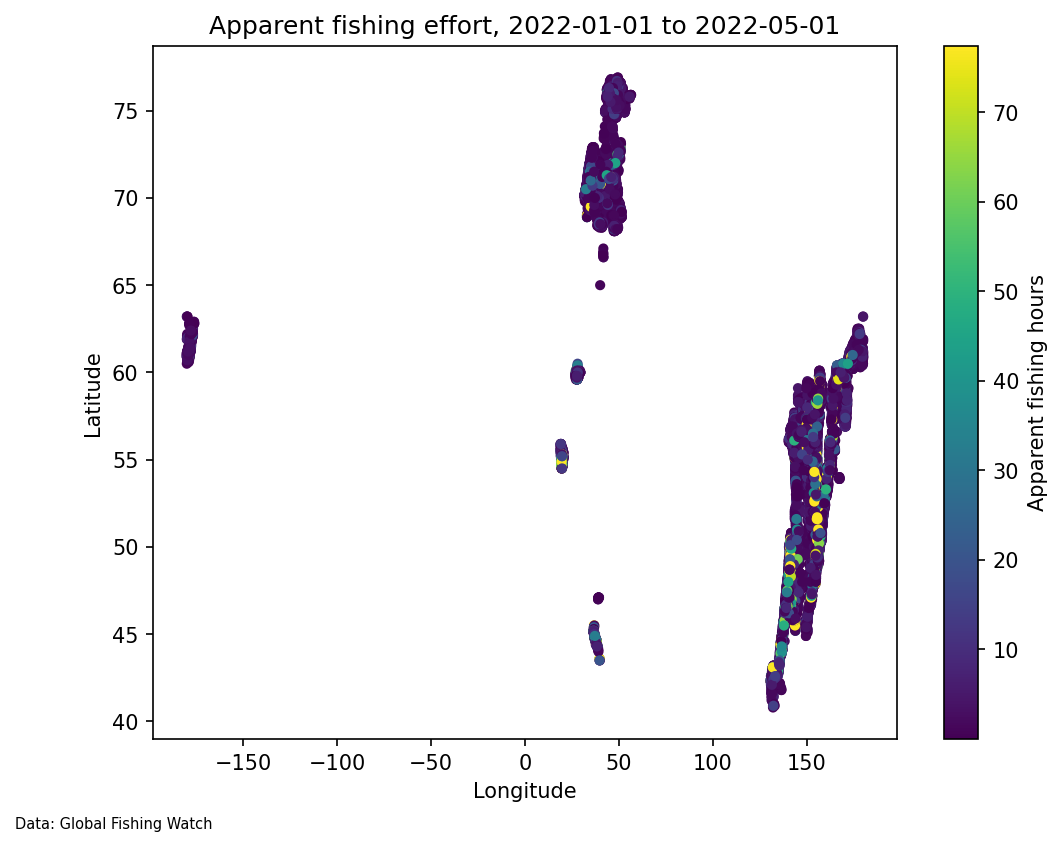

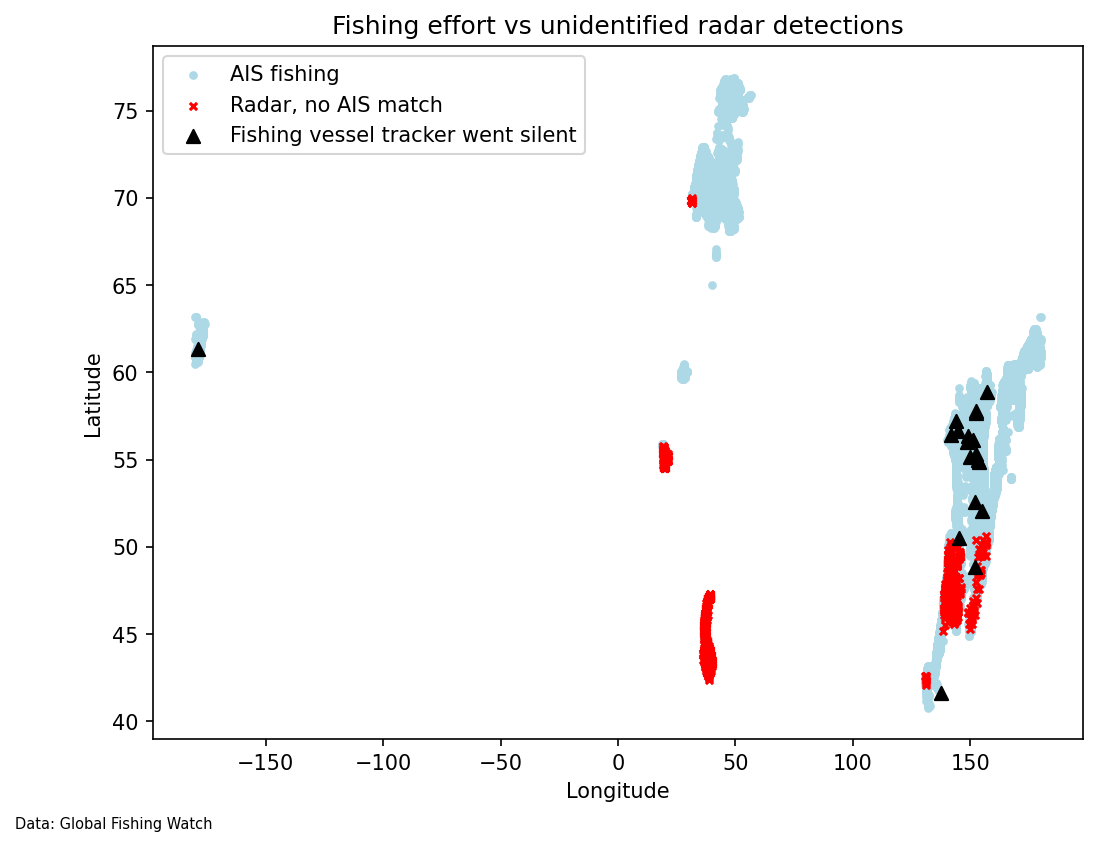

In [10]:
from IPython.display import Image, display
display(Image('output/map_fishing_effort.png'))
display(Image('output/map_unidentified_and_gaps.png'))

## Baseline
Ranks the repeat-gap vessels on fishing-carrier encounters against all fishing vessels in the region. Needs the run above first.

In [ ]:
!oceanwatch baseline
display(Image('output/baseline_histogram.png'))

Pulling all fishing-carrier encounters in the region ...
  encounters page 1: 100 rows, 100 new
  encounters page 2: 100 rows, 100 new
  encounters page 3: 100 rows, 100 new
  encounters page 4: 100 rows, 100 new
  encounters page 5: 100 rows, 100 new
  encounters page 6: 100 rows, 100 new
  encounters page 7: 100 rows, 100 new
  encounters page 8: 100 rows, 100 new
  encounters page 9: 100 rows, 100 new
  encounters page 10: 100 rows, 100 new
  encounters page 11: 100 rows, 100 new
  encounters page 12: 100 rows, 100 new


## Another region or period
Edit and run, e.g. `!oceanwatch run --region-id 8371 --start 2023-01-01 --end 2023-06-01`.

In [ ]:
!oceanwatch run --region-id 5690 --start 2022-01-01 --end 2022-05-01

## Argentina (EEZ 8466), same dates as Russia for comparison

In [ ]:
!oceanwatch run --region-id 8466 --out output_argentina